Saving ADSI_Table_1A.2.csv to ADSI_Table_1A.2 (1).csv
✅ Dataset Loaded | Shape: (93, 14)


,Sl. No.,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323


/tmp/ipython-input-1561787657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Cases', y='State', data=top_states, palette="Reds_r")
/tmp/ipython-input-1561787657.py:24: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


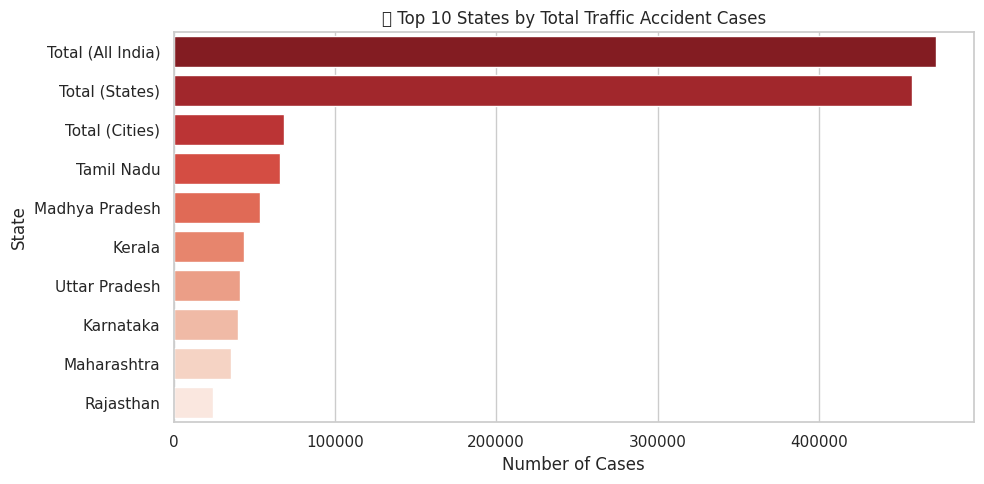

/tmp/ipython-input-1561787657.py:34: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


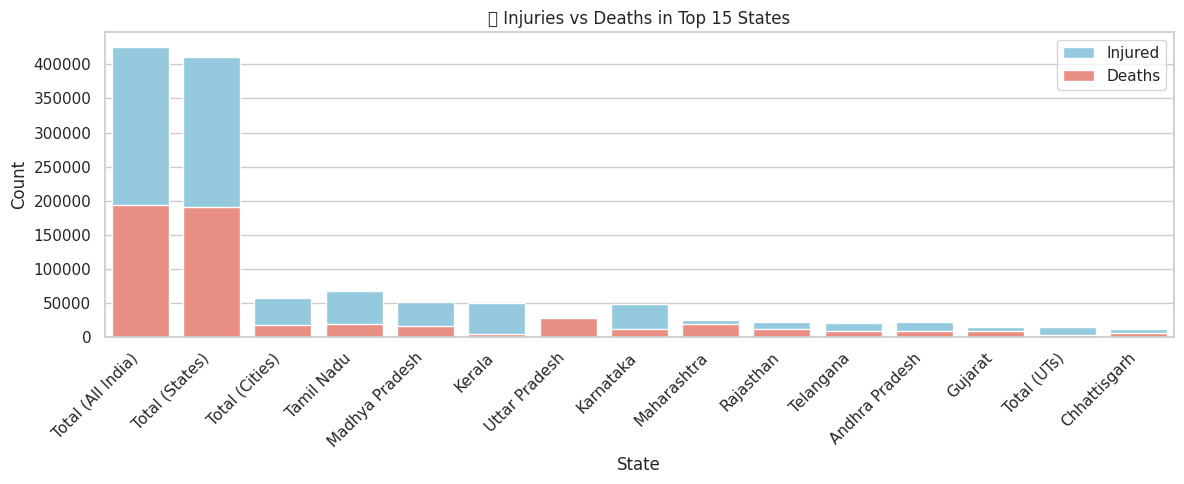

/tmp/ipython-input-1561787657.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Death_Rate', y='State', data=top_death_rate, palette="mako")


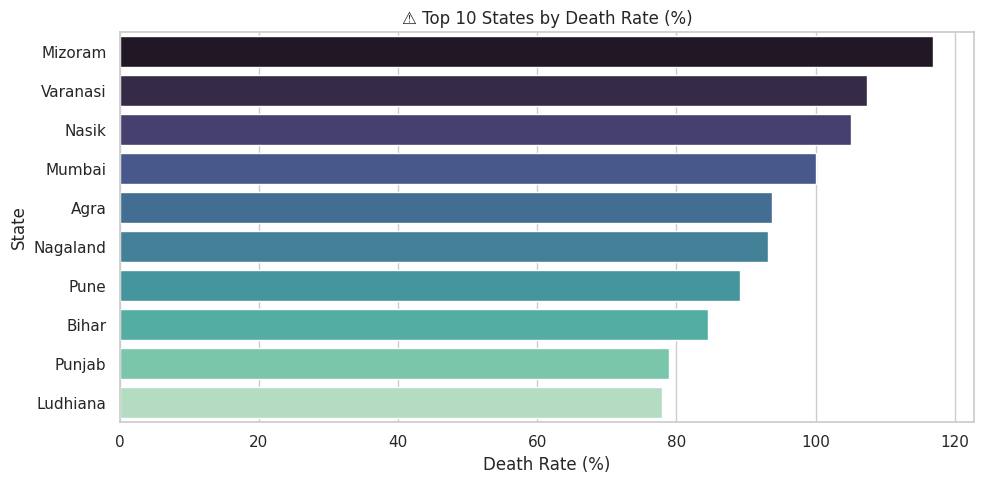

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


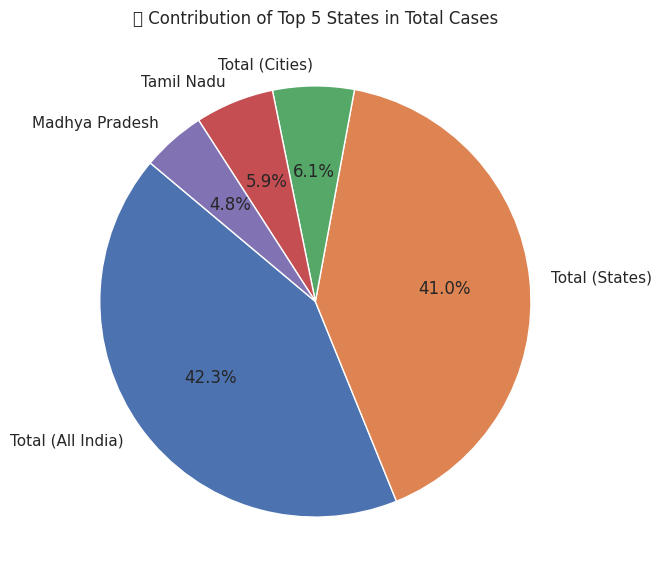

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from google.colab import files
uploaded = files.upload()
import io
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))
print(f"✅ Dataset Loaded | Shape: {df.shape}")
display(df.head())
df.rename(columns={
    'State/UT/City': 'State',
    'Total Traffic Accidents - Cases': 'Total_Cases',
    'Total Traffic Accidents - Injured': 'Total_Injured',
    'Total Traffic Accidents - Died': 'Total_Deaths'
}, inplace=True)
df = df[df['State'].str.lower() != "total"]
top_states = df.sort_values(by='Total_Cases', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Cases', y='State', data=top_states, palette="Reds_r")
plt.title("🚦 Top 10 States by Total Traffic Accident Cases")
plt.xlabel("Number of Cases")
plt.ylabel("State")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,5))
df_sorted = df.sort_values(by='Total_Cases', ascending=False).head(15)
sns.barplot(x='State', y='Total_Injured', data=df_sorted, color='skyblue', label='Injured')
sns.barplot(x='State', y='Total_Deaths', data=df_sorted, color='salmon', label='Deaths')
plt.xticks(rotation=45, ha='right')
plt.title("💥 Injuries vs Deaths in Top 15 States")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
df['Death_Rate'] = (df['Total_Deaths'] / df['Total_Cases']) * 100

plt.figure(figsize=(10,5))
top_death_rate = df.sort_values(by='Death_Rate', ascending=False).head(10)
sns.barplot(x='Death_Rate', y='State', data=top_death_rate, palette="mako")
plt.title("⚠️ Top 10 States by Death Rate (%)")
plt.xlabel("Death Rate (%)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(7,7))
top5 = df.sort_values(by='Total_Cases', ascending=False).head(5)
plt.pie(top5['Total_Cases'], labels=top5['State'], autopct='%1.1f%%', startangle=140)
plt.title("🚗 Contribution of Top 5 States in Total Cases")
plt.show()
